In [ ]:
from pathlib import Path
from datetime import date, timedelta
import os
import numpy as np
import pandas as pd

# Specify the directory path (use "." for the current working directory)
directory_path = Path("./Coles")

# Find all .json files in the top-level directory
jsonl_files = list(directory_path.glob("*.jsonl"))
df_chunks = pd.DataFrame()
chunk_size = 10000
# Print the file paths
for file in jsonl_files:
    chunks = pd.read_json(file, lines=True, chunksize=chunk_size)
    for chunk in chunks:
        df_chuck = pd.DataFrame(chunk)
        df_chunks = pd.concat([df_chunks, df_chuck])

df_chunks.to_csv("df5final.csv")

In [60]:
# select only one product to train, valid and test
# df_chunks = df_chunks.loc[df_chunks['id'] == '424685']

In [61]:
# check for null value
print(df_chunks.isna().sum())

id                        0
availability              0
availabilityType          0
lastUpdated               0
pricing                  30
restrictions             29
size                      0
store                     0
variations             2673
collectableCampaign    3132
internalDescription    3055
continuity             3170
dtype: int64


In [62]:
# most of collectableCampaign, variations, internalDescription are null values so we drop these columns
# drop column store as it has only 1 value
df_chunks.drop(columns=['collectableCampaign', 'variations', 'internalDescription', 'store'], inplace=True)

In [63]:
# check for null value
print(df_chunks.isna().sum())

id                     0
availability           0
availabilityType       0
lastUpdated            0
pricing               30
restrictions          29
size                   0
continuity          3170
dtype: int64


In [64]:
# drop all rows with nan pricing
df_chunks = df_chunks.dropna(subset=['pricing'])

In [65]:
# extract pricing json to columns
for index, row in df_chunks.iterrows():
    item_pricing = df_chunks['pricing'][index]
    for key, value in item_pricing.items():
        if key != 'id':
            if key in df_chunks:
                if type(value) is dict:
                    for subkey, subvalue in value.items():
                        if subkey != 'id':
                            if subkey in df_chunks:
                                df_chunks.at[index, subkey] = subvalue
                            else:
                                df_chunks[subkey] = None
                                df_chunks.at[index, subkey] = subvalue
                else:
                    df_chunks.at[index, key] = value
            else:
                if type(value) is dict:
                    for subkey, subvalue in value.items():
                        if subkey != 'id':
                            if subkey in df_chunks:
                                df_chunks.at[index, subkey] = subvalue
                            else:
                                df_chunks[subkey] = None
                                df_chunks.at[index, subkey] = subvalue
                else:
                    df_chunks[key] = None
                    df_chunks.at[index, key] = value

print(df_chunks.isna().sum())

id                      0
availability            0
availabilityType        0
lastUpdated             0
pricing                 0
restrictions            0
size                    0
continuity           3140
comparable              0
now                     0
onlineSpecial           0
unit                 3170
was                     0
priceDescription      634
promotionType           0
saveAmount              0
savePercent          1231
saveStatement           0
specialType           222
multiBuyPromotion    3170
offerDescription      352
dtype: int64


In [66]:
# extract restrictions json to columns
for index, row in df_chunks.iterrows():
    item_restrictions = df_chunks['restrictions'][index]
    if type(item_restrictions) is dict:
        for key, value in item_restrictions.items():
            if key != 'id':
                if key in df_chunks:
                    if type(value) is dict:
                        for subkey, subvalue in value.items():
                            if subkey != 'id':
                                if subkey in df_chunks:
                                    df_chunks.at[index, subkey] = subvalue
                                else:
                                    df_chunks[subkey] = None
                                    df_chunks.at[index, subkey] = subvalue
                    else:
                        if type(value) is list:
                            value = ", ".join(map(lambda x: str(x), value))
                        else:
                            df_chunks.at[index, key] = value
                else:
                    if type(value) is dict:
                        for subkey, subvalue in value.items():
                            if subkey != 'id':
                                if subkey in df_chunks:
                                    df_chunks.at[index, subkey] = subvalue
                                else:
                                    df_chunks[subkey] = None
                                    df_chunks.at[index, subkey] = subvalue
                    else:
                        df_chunks[key] = None
                        if type(value) is list:
                            value = ", ".join(map(lambda x: str(x), value))
                        else:
                            df_chunks.at[index, key] = value

print(df_chunks.isna().sum())

id                      0
availability            0
availabilityType        0
lastUpdated             0
pricing                 0
restrictions            0
size                    0
continuity           3140
comparable              0
now                     0
onlineSpecial           0
unit                 3170
was                     0
priceDescription      634
promotionType           0
saveAmount              0
savePercent          1231
saveStatement           0
specialType           222
multiBuyPromotion    3170
offerDescription      352
dtype: int64


In [67]:
# remove everything from the index of a substring . onward in each row
df_chunks["lastUpdated"] = df_chunks["lastUpdated"].apply(
    lambda s: s[: s.find('.')] if '.' in s else s
)
# create date column datetime
date_column = pd.to_datetime(df_chunks['lastUpdated'], format='%Y-%m-%dT%H:%M:%S')
# drop column lastUpdated
df_chunks.drop(columns=['lastUpdated'], inplace=True)
df_chunks.insert(0, 'Date', date_column)

In [68]:
df_chunks.drop(columns=['pricing', 'restrictions'], inplace=True)
df_chunks.to_csv("df2.csv")

In [69]:
#print(df_chunk['availability'].value_counts())#True     18233,False     1478
#print(df_chunk['availabilityType'].value_counts())#InStoreAndOnline    19706,InStoreOnly             5
#print(df_chunk['store'].value_counts())#0    19711
#print(df_chunk['minQuantity'].value_counts())#mixed
#print(df_chunk['reward'].value_counts())#mixed
#print(df_chunk['type'].value_counts())#MultibuyMultiSku     1290, MultibuySingleSku      81
#print(df_chunk['now'].value_counts())#mixed, price now
#print(df_chunk['offerDescription'].value_counts())#mixed
#print(df_chunk['onlineSpecial'].value_counts())#False    19524, True       187
#print(df_chunk['promotionType'].value_counts())#mixed
#print(df_chunk['specialType'].value_counts())#MULTI_SAVE           1371,PERCENT_OFF          1148,WHILE_STOCKS_LAST      22
#print(df_chunk['isWeighted'].value_counts())#False    18995,True       375
#print(df_chunk['ofMeasureQuantity'].value_counts())#100    10188,1       6088,10       688
#print(df_chunk['ofMeasureType'].value_counts())#mixed
#print(df_chunk['ofMeasureUnits'].value_counts())#mixed
#print(df_chunk['price'].value_counts())#mixed
#print(df_chunk['quantity'].value_counts())#mixed
#print(df_chunk['was'].value_counts())#mixed
#print(df_chunk['saveAmount'].value_counts())#mixed
#print(df_chunk['saveStatement'].value_counts())#mixed
#print(df_chunk['priceDescription'].value_counts())#mixed
#print(df_chunk['savePercent'].value_counts())#mixed
#print(df_chunk['promotionDescription'].value_counts())#mixed
#print(df_chunk['liquorAgeRestrictionFlag'].value_counts())#False    17590, True      1705
#print(df_chunk['promotionalLimit'].value_counts())#mixed
#print(df_chunk['restrictedByOrganisation'].value_counts())#False    19708
#print(df_chunk['retailLimit'].value_counts())#mixed
#print(df_chunk['tobaccoAgeRestrictionFlag'].value_counts())#False    19065, True       237
#print(df_chunk['delivery'].value_counts())#mixed

In [70]:
# select only one product to train, valid and test
# df_chunks = df_chunks.loc[df_chunks['ofMeasureType'] == 'g']

In [71]:
df_chunks.info()

<class 'pandas.DataFrame'>
Index: 3170 entries, 0 to 99
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               3170 non-null   datetime64[us]
 1   id                 3170 non-null   int64         
 2   availability       3170 non-null   bool          
 3   availabilityType   3170 non-null   str           
 4   size               3170 non-null   str           
 5   continuity         30 non-null     object        
 6   comparable         3170 non-null   object        
 7   now                3170 non-null   object        
 8   onlineSpecial      3170 non-null   object        
 9   unit               0 non-null      object        
 10  was                3170 non-null   object        
 11  priceDescription   2536 non-null   object        
 12  promotionType      3170 non-null   object        
 13  saveAmount         3170 non-null   object        
 14  savePercent        1939 no

In [72]:
# now : current price, we need to predict
# was : previous price
# saveAmount : discounted amount
# savePercent : discounted percentage

# ofMeasureQuantity: unit of Measure Quantity
# price: unit price
# quantity: unit quantity

# convert object columns (actually numeric columns) to float columns
if 'minQuantity' in df_chunks.columns: df_chunks["minQuantity"] = df_chunks["minQuantity"].astype(float)
if 'reward' in df_chunks.columns: df_chunks["reward"] = df_chunks["reward"].astype(float)
if 'now' in df_chunks.columns: df_chunks["now"] = df_chunks["now"].astype(float)
if 'ofMeasureQuantity' in df_chunks.columns: df_chunks["ofMeasureQuantity"] = df_chunks["ofMeasureQuantity"].astype(float)
if 'price' in df_chunks.columns: df_chunks["price"] = df_chunks["price"].astype(float)
if 'quantity' in df_chunks.columns: df_chunks["quantity"] = df_chunks["quantity"].astype(float)
if 'was' in df_chunks.columns: df_chunks["was"] = df_chunks["was"].astype(float)
if 'saveAmount' in df_chunks.columns: df_chunks["saveAmount"] = df_chunks["saveAmount"].astype(float)
if 'savePercent' in df_chunks.columns: df_chunks["savePercent"] = df_chunks["savePercent"].astype(float)
if 'retailLimit' in df_chunks.columns: df_chunks["retailLimit"] = df_chunks["retailLimit"].astype(float)

df_chunks.info()

<class 'pandas.DataFrame'>
Index: 3170 entries, 0 to 99
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               3170 non-null   datetime64[us]
 1   id                 3170 non-null   int64         
 2   availability       3170 non-null   bool          
 3   availabilityType   3170 non-null   str           
 4   size               3170 non-null   str           
 5   continuity         30 non-null     object        
 6   comparable         3170 non-null   object        
 7   now                3170 non-null   float64       
 8   onlineSpecial      3170 non-null   object        
 9   unit               0 non-null      object        
 10  was                3170 non-null   float64       
 11  priceDescription   2536 non-null   object        
 12  promotionType      3170 non-null   object        
 13  saveAmount         3170 non-null   float64       
 14  savePercent        1939 no

In [73]:
# delivery is a list, convert lists into a single comma-separated string, safely ignoring NaNs
# if 'delivery' in df_chunks.columns: df_chunks['delivery'] = df_chunks['delivery'].apply(lambda x: ", ".join(x) if isinstance(x, list) else "empty")

In [74]:
df_chunks.isna().sum()

Date                    0
id                      0
availability            0
availabilityType        0
size                    0
continuity           3140
comparable              0
now                     0
onlineSpecial           0
unit                 3170
was                     0
priceDescription      634
promotionType           0
saveAmount              0
savePercent          1231
saveStatement           0
specialType           222
multiBuyPromotion    3170
offerDescription      352
dtype: int64

In [75]:
# drop continuity because most of that column is nan
df_chunks.drop(columns=['continuity'], inplace=True)


In [76]:
'''from sklearn.preprocessing import LabelEncoder
def tryconvert(col):
    if col.dtype =='object':
        try:
            return labelencoder.fit_transform(col)
        except TypeError as e:
            return col
    else:
        return col
df_chunks = df_chunks.apply(lambda col: tryconvert(col))'''

"from sklearn.preprocessing import LabelEncoder\ndef tryconvert(col):\n    if col.dtype =='object':\n        try:\n            return labelencoder.fit_transform(col)\n        except TypeError as e:\n            return col\n    else:\n        return col\ndf_chunks = df_chunks.apply(lambda col: tryconvert(col))"

In [77]:
# now to use LabelEncoder to encode all string values as categorical data
from sklearn.preprocessing import LabelEncoder
#df_chunks.drop(columns=['delivery'], inplace=True)
labelencoder = LabelEncoder()
df_chunks = df_chunks.apply(lambda col: labelencoder.fit_transform(col) if col.dtype =='object' else col)
df_chunks = df_chunks.apply(lambda col: labelencoder.fit_transform(col) if col.dtype =='str' else col)

In [78]:
df_chunks.info()

<class 'pandas.DataFrame'>
Index: 3170 entries, 0 to 99
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               3170 non-null   datetime64[us]
 1   id                 3170 non-null   int64         
 2   availability       3170 non-null   bool          
 3   availabilityType   3170 non-null   int64         
 4   size               3170 non-null   int64         
 5   comparable         3170 non-null   int64         
 6   now                3170 non-null   float64       
 7   onlineSpecial      3170 non-null   int64         
 8   unit               3170 non-null   int64         
 9   was                3170 non-null   float64       
 10  priceDescription   3170 non-null   int64         
 11  promotionType      3170 non-null   int64         
 12  saveAmount         3170 non-null   float64       
 13  savePercent        1939 non-null   float64       
 14  saveStatement      3170 no

In [79]:
df_chunks.isna().sum()

Date                    0
id                      0
availability            0
availabilityType        0
size                    0
comparable              0
now                     0
onlineSpecial           0
unit                    0
was                     0
priceDescription        0
promotionType           0
saveAmount              0
savePercent          1231
saveStatement           0
specialType             0
multiBuyPromotion       0
offerDescription        0
dtype: int64

In [80]:
# fill all remained nan values
from pandas.api.types import is_numeric_dtype
for attri in df_chunks.columns:
    if is_numeric_dtype(df_chunks):
        avg_value = df_chunks[attri].mean()
        df_chunks[attri] = df_chunks[attri].replace(np.nan,avg_value)
    else:
        counts = df_chunks[attri].value_counts()
        if len(counts) > 0:
            max_freq_value = counts.index[0]
            # if np.nan is the most frequent value 
            if max_freq_value == np.nan:
                max_freq_value = counts.index[1]
            df_chunks[attri] = df_chunks[attri].replace(np.nan, max_freq_value)


In [81]:
df_chunks.isna().sum()

Date                 0
id                   0
availability         0
availabilityType     0
size                 0
comparable           0
now                  0
onlineSpecial        0
unit                 0
was                  0
priceDescription     0
promotionType        0
saveAmount           0
savePercent          0
saveStatement        0
specialType          0
multiBuyPromotion    0
offerDescription     0
dtype: int64

In [82]:
# tmodel = ...
'''model.fit(train)
forecast = model.predict(future)
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
print(f'MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}')'''

"model.fit(train)\nforecast = model.predict(future)\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error\nmse = mean_squared_error(test['y'], forecast_test['yhat'])\nrmse = np.sqrt(mse)\nmae = mean_absolute_error(test['y'], forecast_test['yhat'])\nprint(f'MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}')"

In [83]:
df_chunks.info()

<class 'pandas.DataFrame'>
Index: 3170 entries, 0 to 99
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               3170 non-null   datetime64[us]
 1   id                 3170 non-null   int64         
 2   availability       3170 non-null   bool          
 3   availabilityType   3170 non-null   int64         
 4   size               3170 non-null   int64         
 5   comparable         3170 non-null   int64         
 6   now                3170 non-null   float64       
 7   onlineSpecial      3170 non-null   int64         
 8   unit               3170 non-null   int64         
 9   was                3170 non-null   float64       
 10  priceDescription   3170 non-null   int64         
 11  promotionType      3170 non-null   int64         
 12  saveAmount         3170 non-null   float64       
 13  savePercent        3170 non-null   float64       
 14  saveStatement      3170 no

/var/folders/xy/j2gg75xx0cg1d86dx4k387zm0000gp/T/ipykernel_22358/3836325129.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_chunks['now'],shade=True)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<Axes: xlabel='now', ylabel='Density'>

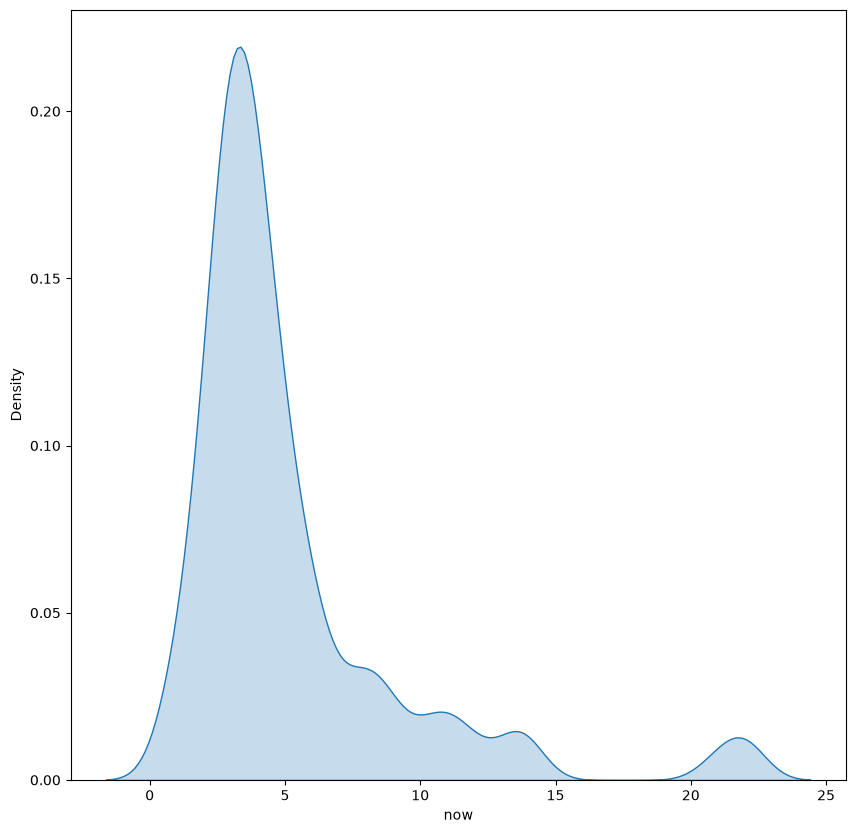

In [84]:
#Summarizing the data with Density plots to see where the mass of the data is located
import matplotlib.pyplot as plt
import seaborn as sns
sns.kdeplot(df_chunks['now'],shade=True)

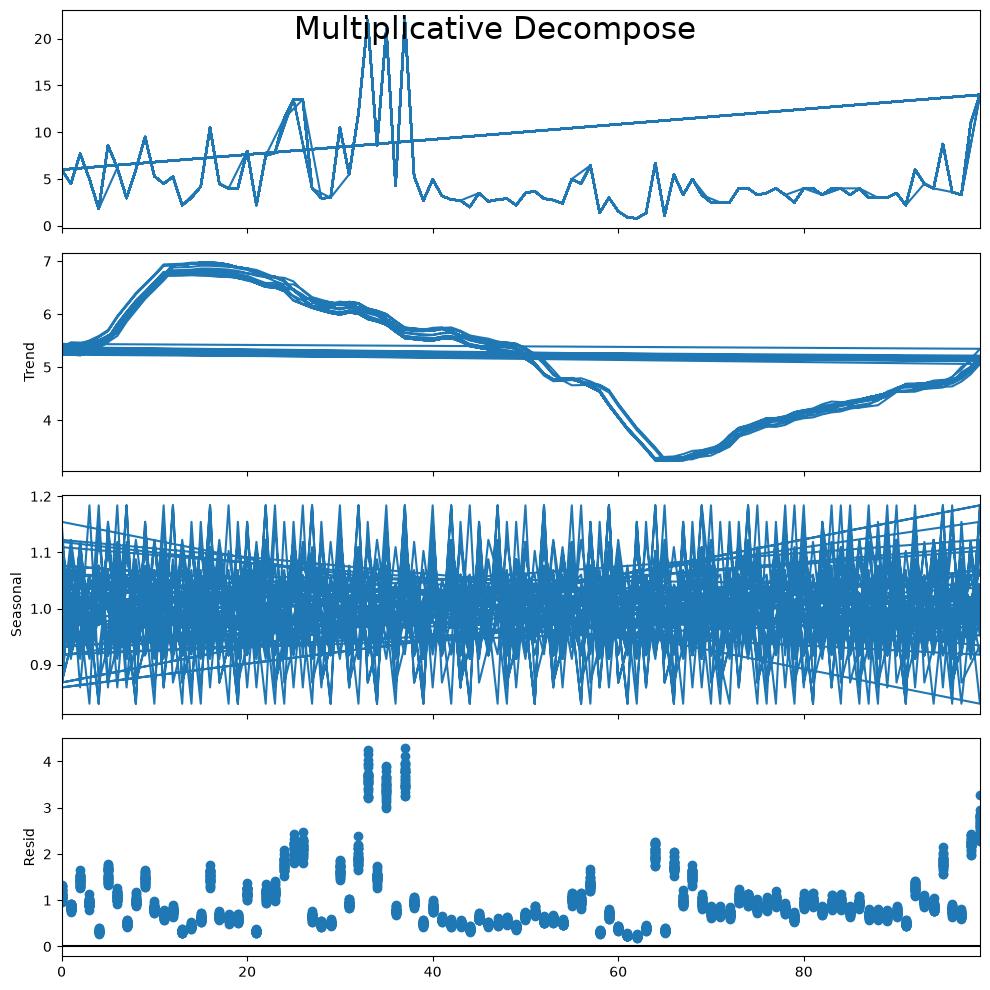

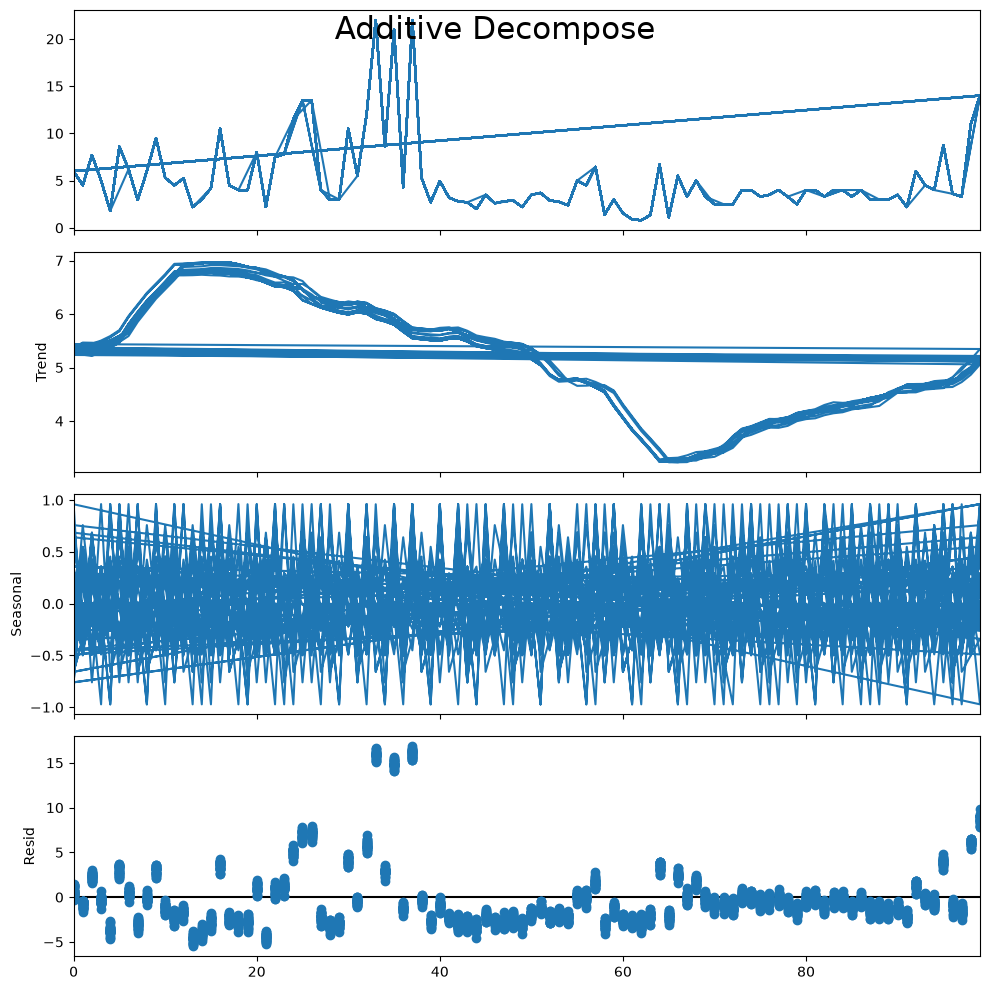

In [85]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

plt.rcParams.update({'figure.figsize': (10,10)})
y = df_chunks['now'].to_frame()


# Multiplicative Decomposition 
result_mul = seasonal_decompose(y, model='multiplicative',period = 52)

# Additive Decomposition
result_add = seasonal_decompose(y, model='additive',period = 52)

# Plot
plt.rcParams.update({'figure.figsize': (10,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

Text(0, 0.5, 'Current price')

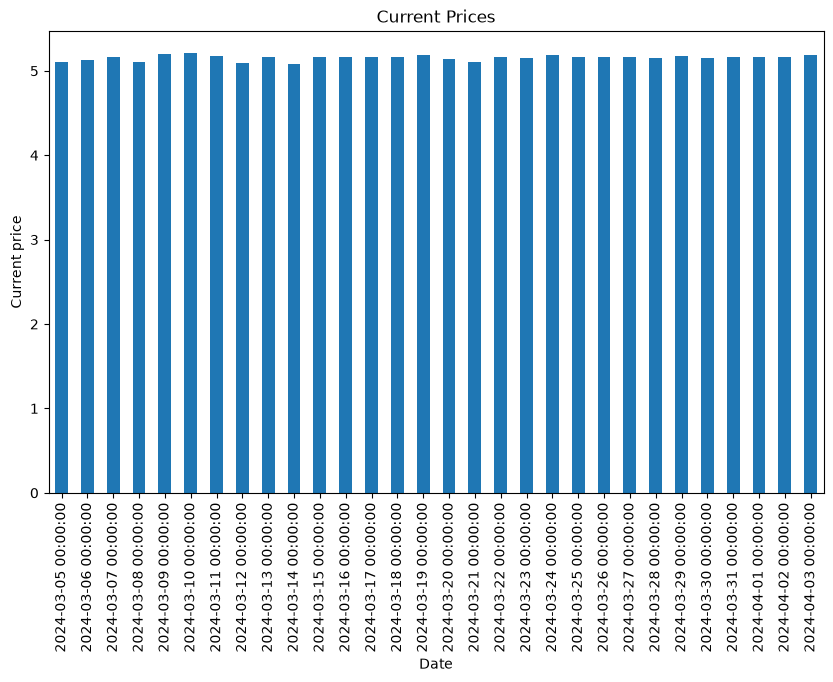

In [86]:
# We can also use time sampling to plot charts for specific columns.
data = df_chunks[['Date','now']]
data['Date'] = data['Date'].apply(pd.to_datetime)
data.set_index('Date',inplace=True)
data['now'].resample('D').mean().plot(kind='bar', figsize=(10,6),title='Current Prices')
plt.ylabel('Current price')

<Axes: >

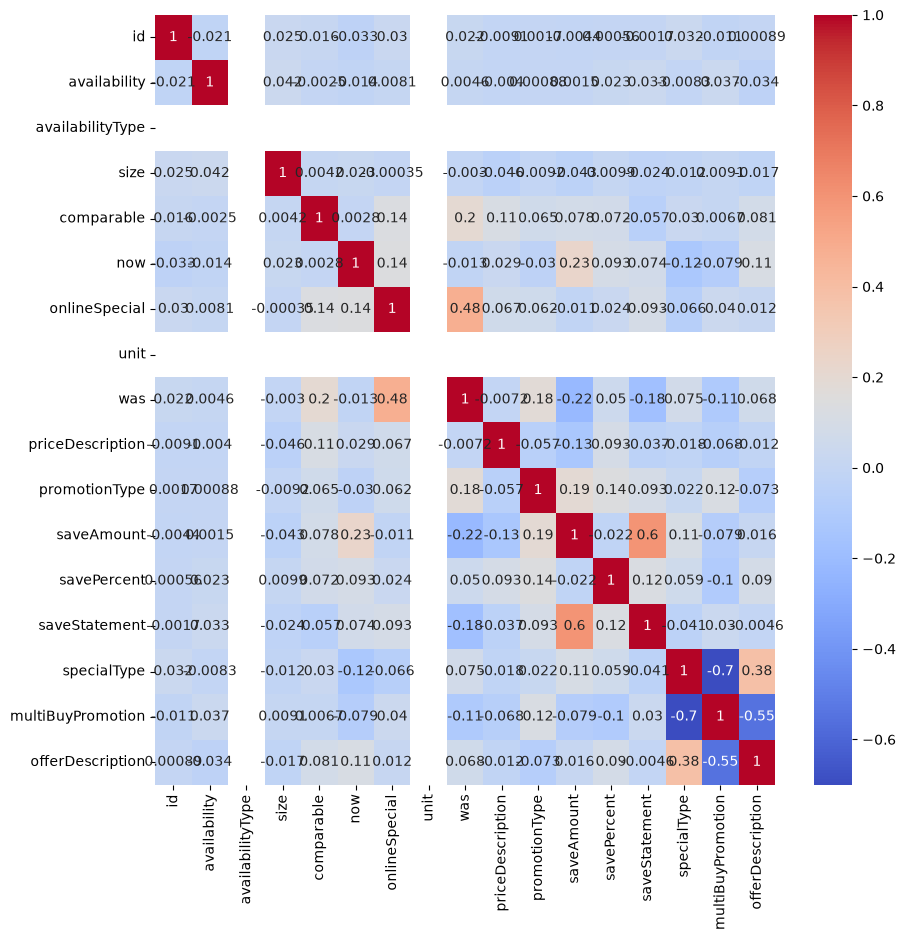

In [87]:
# Check correlation matrix
sns.heatmap(df_chunks.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [88]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, Dropout, GlobalAveragePooling1D
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

df = df_chunks.copy()
data = df[['now']].values
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

# Parameters
time_step = 100
training_size = int(len(data_scaled) * 0.67)
test_size = len(data_scaled) - training_size
train_data, test_data = data_scaled[0:training_size,:], data_scaled[training_size:len(data_scaled),:]

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape input for the model
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Transformer Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return x + res

# Model Definition
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = transformer_encoder(inputs, head_size=256, num_heads=4, ff_dim=4, dropout=0.1)
x = GlobalAveragePooling1D(data_format='channels_first')(x)
x = Dropout(0.1)(x)
x = Dense(20, activation="relu")(x)
outputs = Dense(1, activation="linear")(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mean_squared_error")

# Model Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 1)    │          2 │ input_layer_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 1)    │      7,169 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 100, 1)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 1)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 1)    │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100, 4)    │          8 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 100, 4)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100, 1)    │          5 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 100, 1)    │          0 │ dense_5[0][0],    │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ add_3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 100)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │      2,020 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         21 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,227 (36.04 KB)

 Trainable params: 9,227 (36.04 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Train the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=64, verbose=1)
#model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64, verbose=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Evaluate the model\
train_mse = mean_squared_error(y_train, scaler.inverse_transform(train_predict.reshape(-1, 1)))
train_rmse = math.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, scaler.inverse_transform(train_predict.reshape(-1, 1)))
test_mse = mean_squared_error(y_test, scaler.inverse_transform(test_predict.reshape(-1, 1)))
test_rmse = math.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, scaler.inverse_transform(test_predict.reshape(-1, 1)))
print(f'Train MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}')
print(f'Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}')

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.3383 - val_loss: 0.1278
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1728 - val_loss: 0.1000
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1326 - val_loss: 0.0844
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1126 - val_loss: 0.0717
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0942 - val_loss: 0.0630
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0787 - val_loss: 0.0531
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0663 - val_loss: 0.0457
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0583 - val_loss: 0.0395
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0510 - val_loss: 0.0340
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0409 - val_loss: 0.0300
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0373 - val_loss: 0.0259
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0

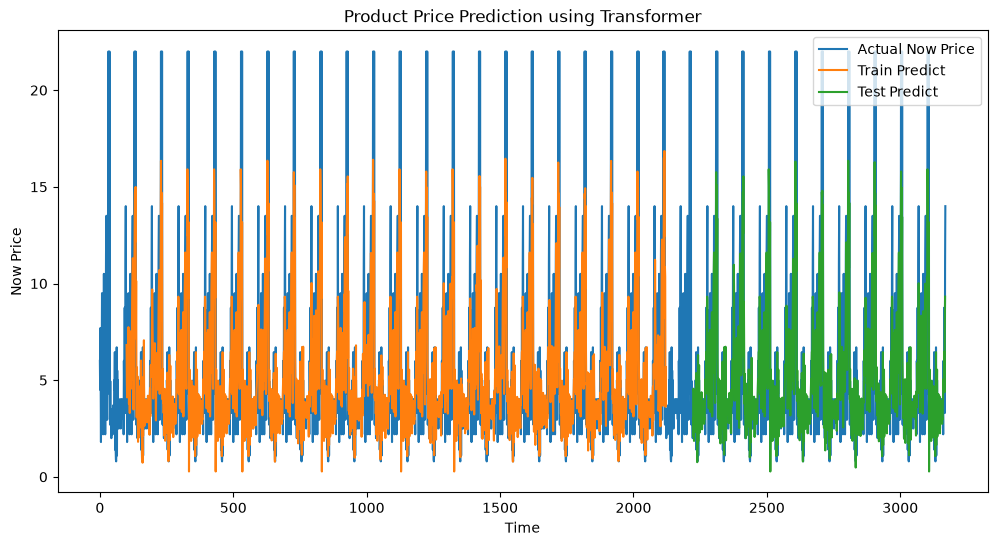

In [90]:
# Plotting the results
# Adjust the time_step offset for plotting
trainPredictPlot = np.empty_like(data_scaled)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[time_step:len(train_predict)+time_step, :] = train_predict

# Shift test predictions for plotting
testPredictPlot = np.empty_like(data_scaled)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(time_step*2)+1:len(data_scaled)-1, :] = test_predict

# Plot baseline and predictions
plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(data_scaled), label='Actual Now Price')
plt.plot(trainPredictPlot, label='Train Predict')
plt.plot(testPredictPlot, label='Test Predict')
plt.title('Product Price Prediction using Transformer')
plt.xlabel('Time')
plt.ylabel('Now Price')
plt.legend()
plt.show()